In [1]:
import pandas as pd
import numpy as np
import netCDF4 as nc
import xarray as xr
from scipy.spatial import cKDTree
import cmocean.cm as cm
from salishsea_tools import viz_tools
import matplotlib.pyplot as plt

In [2]:
# Parameters
input_data_nc = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon.nc"
mesh_mask_nc = "/ocean/atall/MOAD/grid/mesh_mask_202310b.nc"
output_nc = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid.nc"

In [3]:
# Read input files
ds_data = xr.open_dataset(input_data_nc)
ds_mask = xr.open_dataset(mesh_mask_nc)

ds_data

<xarray.Dataset>
Dimensions:  (source: 99, date: 6787)
Coordinates:
  * source   (source) int64 1 2 3 4 5 6 7 8 9 10 ... 91 92 93 94 95 96 97 98 99
  * date     (date) datetime64[ns] 1999-01-01 1999-01-02 ... 2017-07-31
Data variables: (12/13)
    ID       (source) int64 ...
    lon      (source) float64 ...
    lat      (source) float64 ...
    name     (source) object ...
    flow     (source, date) float64 ...
    temp     (source, date) float64 ...
    ...       ...
    NH4      (source, date) float64 ...
    TIC      (source, date) float64 ...
    Talk     (source, date) float64 ...
    DO       (source, date) float64 ...
    DON      (source, date) float64 ...
    PON      (source, date) float64 ...
Attributes:
    description:  Ecology data for point sources

In [14]:
# Extract model grid coordinates and ocean mask 
nav_lon = ds_mask["nav_lon"].values
nav_lat = ds_mask["nav_lat"].values
#tmask = ds_mask["tmaskutil"].isel(t=0).values.astype(bool)
tmask = ds_mask["tmask"].isel(t=0, z=0).values.astype(bool)

ny, nx = nav_lon.shape
latlon_masked = np.column_stack((nav_lat[tmask], nav_lon[tmask]))

In [5]:
# Build KD-tree for nearest-neighbor search on ocean points
tree = cKDTree(latlon_masked)

station_lats = ds_data["lat"].values
station_lons = ds_data["lon"].values
station_names = ds_data["name"].values

station_indices = []
grid_yx_indices = []

# Map each station to the nearest ocean grid cell
for i, (lat, lon) in enumerate(zip(station_lats, station_lons)):
    dist, idx = tree.query([lat, lon])
    yx = np.argwhere(tmask)[idx]
    y, x = yx
    grid_yx_indices.append((y, x))
    station_indices.append(i)

In [6]:
# Prepare time and grid dimensions 
time = ds_data["date"].values
n_time = len(time)
n_y, n_x = nav_lat.shape

def init_field():
    # Initialize output field with NaNs
    return np.full((n_time, n_y, n_x), np.nan)

In [15]:
# Variables to process: mapping from input to output names and metadata 
variable_map = {
    "flow": ("flux", "kg m-2 s-1", "wastewater_flux"),
    "temp": ("temperature", "oC", "wastewater conservative temperature"),
    "NO3": ("NO3", "umol/L", "wastewater Nitrate + Nitrite"),
    "NH4": ("NH3", "umol/L", "wastewater ammonium"),
    "DO": ("oxygen", "umol/L", "dissolved oxygen"),
    "Talk": ("alkalinity", "umol/L", "carbonate alkalinity"),
    "TIC": ("DIC", "umol/L", "dissolved inorganic carbon"),
    "PON": ("PON", "umol/L", "wastewater labile particulate organic nitrogen"),
    "DON": ("DON", "umol/L", "wastewater labile dissolved organic nitrogen"),
}

fields = {vname: init_field() for _, (vname, _, _) in variable_map.items()}


KeyboardInterrupt: 

In [ ]:
# Fill data fields onto model grid 
for i, (y, x) in zip(station_indices, grid_yx_indices):
    for orig_var, (target_var, unit, long_name) in variable_map.items():
        if orig_var not in ds_data:
            continue
        data = ds_data[orig_var][i, :].values
        if target_var == "flux":
            # Convert flow (m3/s) to flux (kg/m2/s)
            rho = 1000  # kg/m3
            cell_area = ds_mask["e1t"].isel(t=0).values[y, x] * ds_mask["e2t"].isel(t=0).values[y, x]
            data = (data * rho) / cell_area
        fields[target_var][:, y, x] = data

In [9]:
# Create output NetCDF file 
output_metadata = {vname: (unit, long_name) for _, (vname, unit, long_name) in variable_map.items()}

with nc.Dataset(output_nc, "w") as ds_out:
    # Dimensions
    ds_out.createDimension("time_counter", None)
    ds_out.createDimension("x", n_x)
    ds_out.createDimension("y", n_y)

    # Coordinates
    ds_out.createVariable("nav_lon", "f4", ("y", "x"))[:] = nav_lon
    ds_out["nav_lon"].units = "degrees_east"
    ds_out["nav_lon"].long_name = "latitude"

    ds_out.createVariable("nav_lat", "f4", ("y", "x"))[:] = nav_lat
    ds_out["nav_lat"].units = "degrees_north"
    ds_out["nav_lat"].long_name = "latitude"

    ds_out.createVariable("time_counter", "i8", ("time_counter",))[:] = time

    area = ds_mask["e1t"].isel(t=0).values * ds_mask["e2t"].isel(t=0).values
    ds_out.createVariable("area", "f8", ("y", "x"))[:] = area
    ds_out["area"].units = "m2"
    ds_out["area"].long_name = "horizontal_grid_cell_area"

    # Output fields
    for varname, data in fields.items():
        v = ds_out.createVariable(varname, "f8", ("time_counter", "y", "x"), fill_value=np.nan)
        v[:] = data
        v.units = output_metadata[varname][0]
        v.long_name = output_metadata[varname][1]

In [ ]:
##################### NOT USED - takes a lot of memory ############################
def compute_and_save_climatology(input_nc, output_nc):
    with nc.Dataset(input_nc, "r") as src:
        nav_lon = src["nav_lon"][:]
        nav_lat = src["nav_lat"][:]
        area = src["area"][:]
        time = src["time_counter"][:]
        varnames = [v for v in src.variables if v not in ["nav_lon", "nav_lat", "time_counter", "area"]]
        fields = {v: src[v][:] for v in varnames}
        metadata = {v: (src[v].units, src[v].long_name) for v in varnames}

    n_y, n_x = nav_lon.shape
    climatology = {v: np.zeros((12, n_y, n_x)) for v in varnames}

    # Convert numeric time to datetime and group by month
    dates = np.array([np.datetime64("1950-01-01") + np.timedelta64(int(t), 'D') for t in time])

    for month in range(1, 13):
        indices = [i for i, d in enumerate(dates) if (d.astype('datetime64[M]').astype(int) % 12 + 1) == month]
        for var in varnames:
            if indices:
                month_data = fields[var][indices, :, :]
                clim = np.nanmean(month_data, axis=0)
            else:
                clim = np.full((n_y, n_x), np.nan)
            climatology[var][month - 1] = clim  # Keep NaNs (do not replace with zeros here)

    # Write to NetCDF in NEMO-compatible structure
    with nc.Dataset(output_nc, "w") as ds_out:
        # Dimensions
        ds_out.createDimension("time_counter", None)
        ds_out.createDimension("x", n_x)
        ds_out.createDimension("y", n_y)

        # x and y variables
        vx = ds_out.createVariable("x", "i8", ("x",))
        vx[:] = np.arange(n_x)
        vy = ds_out.createVariable("y", "i8", ("y",))
        vy[:] = np.arange(n_y)

        # Coordinates
        vlon = ds_out.createVariable("nav_lon", "f4", ("y", "x"), fill_value=np.nan)
        vlon[:] = nav_lon
        vlon.units = "degrees_east"
        vlon.long_name = "longitude"

        vlat = ds_out.createVariable("nav_lat", "f4", ("y", "x"), fill_value=np.nan)
        vlat[:] = nav_lat
        vlat.units = "degrees_north"
        vlat.long_name = "latitude"

        varea = ds_out.createVariable("area", "f8", ("y", "x"), fill_value=np.nan)
        varea[:] = area
        varea.units = "m2"
        varea.long_name = "horizontal_grid_cell_area"

        vtime = ds_out.createVariable("time_counter", "i8", ("time_counter",))
        vtime[:] = np.arange(1, 13)
        vtime.units = "month"
        vtime.long_name = "climatology_month"

        # Variables
        for var in varnames:
            v = ds_out.createVariable(var, "f8", ("time_counter", "y", "x"), fill_value=np.nan, zlib=True)
            v.units = metadata[var][0]
            v.long_name = metadata[var][1]
            v[:] = climatology[var]

        # Global attributes
        ds_out.acknowledgements = "Based on Ecology data for point sources"
        ds_out.creator_email = "atall@eoas.ubc.ca"
        ds_out.creator_name = "UBC Salish Sea Project Contributors"
        ds_out.creator_url = "https://salishsea-meopar-docs.readthedocs.org/"
        ds_out.institution = "UBC EOAS"
        ds_out.institution_fullname = "Earth, Ocean & Atmospheric Sciences, University of British Columbia"
        ds_out.title = "wastewater_moh20"
        ds_out.comment = "wastewater_mohamedali_et_al_2020 + Aurora Leeson on coordinates_seagrid_SalishSea201702.nc"
        ds_out.notebook = "generate_wwtp_data.ipynb"
        ds_out.summary = "Wastewater, flux, area, and conservative temperature"
        ds_out.history = "[2025-08-15] File creation."


In [ ]:
#compute_and_save_climatology("/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid.nc",
#                              "/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc") # takes a lot of memory and time


#### Compute and save the climatological file

In [16]:
input_nc = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid.nc"
ds = xr.open_dataset(input_nc, chunks={"time_counter": 365})
ds

<xarray.Dataset>
Dimensions:       (y: 898, x: 398, time_counter: 6787)
Coordinates:
  * time_counter  (time_counter) int64 915148800000000000 ... 150145920000000...
Dimensions without coordinates: y, x
Data variables:
    nav_lon       (y, x) float32 dask.array<chunksize=(898, 398), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(898, 398), meta=np.ndarray>
    area          (y, x) float64 dask.array<chunksize=(898, 398), meta=np.ndarray>
    flux          (time_counter, y, x) float64 dask.array<chunksize=(365, 898, 398), meta=np.ndarray>
    temperature   (time_counter, y, x) float64 dask.array<chunksize=(365, 898, 398), meta=np.ndarray>
    NO3           (time_counter, y, x) float64 dask.array<chunksize=(365, 898, 398), meta=np.ndarray>
    NH3           (time_counter, y, x) float64 dask.array<chunksize=(365, 898, 398), meta=np.ndarray>
    oxygen        (time_counter, y, x) float64 dask.array<chunksize=(365, 898, 398), meta=np.ndarray>
    alkalinity    (time_counter, y, x) float64 dask.array<chunksize=(365, 898, 398), meta=np.ndarray>
    DIC           (time_counter, y, x) float64 dask.array<chunksize=(365, 898, 398), meta=np.ndarray>
    PON           (time_counter, y, x) float64 dask.array<chunksize=(365, 898, 398), meta=np.ndarray>
    DON           (time_counter, y, x) float64 dask.array<chunksize=(365, 898, 398), meta=np.ndarray>

In [5]:
if not np.issubdtype(ds["time_counter"].dtype, np.datetime64):
    ds["time_counter"] = xr.cftime_range("2000-01-01", periods=ds.dims["time_counter"], freq="D")


In [6]:
clim = ds.groupby("time_counter.month").mean(dim="time_counter", skipna=True)
clim = clim.rename({"month": "time_counter"})
clim = clim.assign_coords(time_counter=np.arange(1, 13))


In [7]:
# Replace NaN with zeros
for var in clim.data_vars:
    clim[var] = clim[var].fillna(0.0)


In [ ]:
var_metadata = {
    "flux": ("kg m-2 s-1", "wastewater_flux"),
    "temperature": ("oC", "wastewater conservative temperature"),
    "NO3": ("umol/L", "wastewater Nitrate + Nitrite"),
    "NH3": ("umol/L", "wastewater ammonium"),
    "dSi": ("umol/L", "wastewater dissolved silicon"),
    "diatoms": ("umol/L", "wastewater diatoms"),
    "nanoflagellates": ("umol/L", "wastewater nanoflagellates"),
    "Z1": ("umol/L", "wastewater Z1 zooplankton"),
    "PON": ("umol/L", "wastewater particulate organic nitrogen"),
    "DON": ("umol/L", "wastewater labile dissolved organic nitrogen"),
    "bSi": ("umol/L", "biogenic silicon"),
    "oxygen": ("umol/L", "dissolved oxygen"),
    "alkalinity": ("umol/L", "carbonate alkalinity"),
    "DIC": ("umol/L", "dissolved inorganic carbon"),
    "turb": ("NTU", "turbidity")
}

for var, (units, long_name) in var_metadata.items():
    if var in clim:
        clim[var].attrs["units"] = units
        clim[var].attrs["long_name"] = long_name
        clim[var].attrs["_FillValue"] = np.nan
# Add attributes for nav_lon, nav_lat, area
clim["nav_lon"].attrs = {"units": "degrees_east", "long_name": "longitude", "_FillValue": np.nan}
clim["nav_lat"].attrs = {"units": "degrees_north", "long_name": "latitude", "_FillValue": np.nan}
clim["area"].attrs = {"units": "m2", "long_name": "horizontal_grid_cell_area", "_FillValue": np.nan}


In [14]:
# Add global attributes
clim.attrs.update({
    "acknowledgements": "Based on Ecology data from the University of Washington for point sources",
    "creator_email": "atall@eoas.ubc.ca",
    "creator_name": "UBC Salish Sea Project Contributors",
    "creator_url": "https://salishsea-meopar-docs.readthedocs.org/",
    "institution": "UBC EOAS",
    "institution_fullname": "Earth, Ocean & Atmospheric Sciences, University of British Columbia",
    "title": "Wastewater Climatology from wwtp_data_mohamedali_etal_2020 (1999-Jul 2017) + Aurora Leeson (Aug 2017-2020)",
    "comment": "Monthly climatology computed from all_point_source_data_donpon_xygrid.nc",
    "notebook": "generate_wwtp_data.ipynb",
    "summary": "Wastewater climatology, flux, area, and conservative temperature",
    "history": f"[{pd.Timestamp.now().strftime('%Y-%m-%d')}] Climatology file creation."
})

In [ ]:
# Save as NetCDF (NEMO-compatible) : takes ~35 minutes
output_nc = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc"

encoding = {var: {"zlib": True, "_FillValue": np.nan} for var in clim.data_vars}
for coord in clim.coords:
    encoding[coord] = {"zlib": False}

clim.to_netcdf(
    output_nc,
    format="NETCDF4",
    unlimited_dims=["time_counter"],
    encoding=encoding
)

print(f"Climatology saved to {output_nc}")


Climatology saved to /ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc


#### Plots 

In [4]:
ds = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc")
ds = ds.assign_coords(time_counter=ds.time_counter - 1)  # Adjust month indexing from 1-12 to 0-11
ds

<xarray.Dataset>
Dimensions:       (time_counter: 12, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) int64 0 1 2 3 4 5 6 7 8 9 10 11
Dimensions without coordinates: y, x
Data variables:
    nav_lon       (time_counter, y, x) float32 ...
    nav_lat       (time_counter, y, x) float32 ...
    area          (time_counter, y, x) float64 ...
    flux          (time_counter, y, x) float64 ...
    temperature   (time_counter, y, x) float64 ...
    NO3           (time_counter, y, x) float64 ...
    NH3           (time_counter, y, x) float64 ...
    oxygen        (time_counter, y, x) float64 ...
    alkalinity    (time_counter, y, x) float64 ...
    DIC           (time_counter, y, x) float64 ...
    PON           (time_counter, y, x) float64 ...
    DON           (time_counter, y, x) float64 ...
Attributes:
    acknowledgements:      Based on Ecology data from the University of Washi...
    creator_email:         atall@eoas.ubc.ca
    creator_name:          UBC Salish Sea Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 Wastewater Climatology from wwtp_data_mohamedali_e...
    comment:               Monthly climatology computed from all_point_source...
    notebook:              generate_wwtp_data.ipynb
    summary:               Wastewater climatology, flux, area, and conservati...
    history:               [2025-08-18] Climatology file creation.

In [5]:
input_iona_nc = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20231010_iona.nc"
ds_iona = xr.open_dataset(input_iona_nc)
ds_iona

<xarray.Dataset>
Dimensions:          (x: 398, y: 898, time_counter: 12)
Coordinates:
  * x                (x) int64 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
  * y                (y) int64 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * time_counter     (time_counter) int64 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 ...
    nav_lon          (y, x) float32 ...
    area             (y, x) float64 ...
    flux             (time_counter, y, x) float64 ...
    temperature      (time_counter, y, x) float64 ...
    NO3              (time_counter, y, x) float64 ...
    ...               ...
    DON              (time_counter, y, x) float64 ...
    bSi              (time_counter, y, x) float64 ...
    oxygen           (time_counter, y, x) float64 ...
    alkalinity       (time_counter, y, x) float64 ...
    DIC              (time_counter, y, x) float64 ...
    turb             (time_counter, y, x) float64 ...
Attributes:
    acknowledgements:      Based on Metro Data File
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          UBC Salish Sea Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 wastewater_20231010
    comment:               wastewater_20231010 on coordinates_seagrid_SalishS...
    notebook:              Wastewater_File.ipynb
    summary:               Wastewater, flux, area, and conservative temperature
    history:               [2023-10-10] File creation.

In [8]:
var_metadata = {
    "flux": {"units": "mol/m2/s", "long_name": "wastewater flux"},
    "temperature": {"units": "°C", "long_name": "wastewater temperature"},
    "NO3": {"units": "umol/L", "long_name": "wastewater nitrate"},
    "NH3": {"units": "umol/L", "long_name": "wastewater ammonium"},
    "dSi": {"units": "umol/L", "long_name": "wastewater dissolved silicon"},
    "diatoms": {"units": "umol/L", "long_name": "wastewater diatoms"},
    "nanoflagellates": {"units": "umol/L", "long_name": "wastewater nanoflagellates"},
    "Z1": {"units": "umol/L", "long_name": "wastewater Z1 zooplankton"},
    "PON": {"units": "umol/L", "long_name": "particulate organic nitrogen"},
    "DON": {"units": "umol/L", "long_name": "dissolved organic nitrogen"},
    "bSi": {"units": "umol/L", "long_name": "biogenic silicon"},
    "oxygen": {"units": "umol/L", "long_name": "oxygen"},
    "alkalinity": {"units": "umol/L", "long_name": "alkalinity"},
    "DIC": {"units": "umol/L", "long_name": "dissolved inorganic carbon"},
    "turb": {"units": "NTU", "long_name": "turbidity"},
}

vars_to_add = ["flux","DIC","DON","PON","NO3","NH3",
               "oxygen","alkalinity","temperature"]
for v in vars_to_add:
    ds_iona[v] = ds_iona[v] + ds[v]
    ds_iona[v].attrs.update(var_metadata[v])
    
for v in set(ds_iona.data_vars) - {"nav_lat","nav_lon","area"}:
    ds_iona[v].encoding["_FillValue"] = 0.0
    ds_iona[v].encoding["dtype"] = "float64"
for v in ["nav_lat", "nav_lon", "area"]:
    ds_iona[v].encoding["_FillValue"] = None
ds_iona = ds_iona.fillna(0)


In [9]:
ds_iona

<xarray.Dataset>
Dimensions:          (y: 898, x: 398, time_counter: 12)
Coordinates:
  * x                (x) int64 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
  * y                (y) int64 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * time_counter     (time_counter) int64 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 46.86 46.86 46.86 46.87 ... 51.1 51.1 51.1
    nav_lon          (y, x) float32 -123.4 -123.4 -123.4 ... -124.3 -124.3
    area             (y, x) float64 1.852e+05 1.908e+05 ... 1.764e+05 1.755e+05
    flux             (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    temperature      (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    NO3              (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...               ...
    DON              (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    bSi              (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    oxygen           (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    alkalinity       (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    DIC              (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    turb             (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    acknowledgements:      Based on Metro Data File
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          UBC Salish Sea Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 wastewater_20231010
    comment:               wastewater_20231010 on coordinates_seagrid_SalishS...
    notebook:              Wastewater_File.ipynb
    summary:               Wastewater, flux, area, and conservative temperature
    history:               [2023-10-10] File creation.

In [114]:
ds_iona.attrs.update({
    "acknowledgements": "Based on Metro Data File and Ecology data from the University of Washington for point sources",
    "creator_email": "sallen@eoas.ubc.ca and atall@eoas.ubc.ca",
    "creator_name": "UBC Salish Sea Project Contributors",
    "creator_url": "https://salishsea-meopar-docs.readthedocs.org/",
    "institution": "UBC EOAS",
    "institution_fullname": "Earth, Ocean & Atmospheric Sciences, University of British Columbia",
    "title": "Iona + Wastewater Climatology from wwtp_data_mohamedali_etal_2020 (1999-Jul 2017) + Aurora Leeson (Aug 2017-2020)",
    "comment": "Monthly climatology computed from all_point_source_data_donpon_xygrid.nc and Iona data",
    "notebook": "generate_wwtp_grid_data.ipynb",
    "summary": "Wastewater climatology, flux, area, and conservative temperature",
    "history": f"[{pd.Timestamp.now().strftime('%Y-%m-%d')}] Climatology file creation."
})

In [115]:
ds_iona.to_netcdf(
    "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20251118.nc",
    format="NETCDF4",
    unlimited_dims=["time_counter"])

In [116]:
ds_iona

<xarray.Dataset>
Dimensions:          (y: 898, x: 398, time_counter: 12)
Coordinates:
  * x                (x) int64 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
  * y                (y) int64 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * time_counter     (time_counter) int64 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 46.86 46.86 46.86 46.87 ... 51.1 51.1 51.1
    nav_lon          (y, x) float32 -123.4 -123.4 -123.4 ... -124.3 -124.3
    area             (y, x) float64 1.852e+05 1.908e+05 ... 1.764e+05 1.755e+05
    flux             (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    temperature      (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    NO3              (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...               ...
    DON              (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    bSi              (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    oxygen           (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    alkalinity       (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    DIC              (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    turb             (time_counter, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    acknowledgements:      Based on Metro Data File and Ecology data from the...
    creator_email:         sallen@eoas.ubc.ca and atall@eoas.ubc.ca
    creator_name:          UBC Salish Sea Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 Iona + Wastewater Climatology from wwtp_data_moham...
    comment:               Monthly climatology computed from all_point_source...
    notebook:              generate_wwtp_grid_data.ipynb
    summary:               Wastewater climatology, flux, area, and conservati...
    history:               [2025-11-20] Climatology file creation.

In [10]:
#vars_to_cancel = ["turb","DIC","DON","PON","NO3","NH3",
#               "oxygen","alkalinity","bSi","dSi","diatoms",
#               "nanoflagellates","Z1"]
vars_to_cancel = ["turb","DIC","DON","PON",#"NO3","NH3",
               "oxygen","alkalinity","bSi","dSi","diatoms",
               "nanoflagellates","Z1"]
for v in vars_to_cancel:
    ds_iona[v] = ds_iona[v] * 0.0
    ds_iona[v].attrs.update(var_metadata[v])

In [11]:
#ds_iona.to_netcdf(
#    "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20251118_freshwater.nc",
#    format="NETCDF4",
#    unlimited_dims=["time_counter"])
ds_iona.to_netcdf(
    "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20251118_NO3NH3.nc",
    format="NETCDF4",
    unlimited_dims=["time_counter"])

In [12]:
wwtp_all = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20251118_NO3NH3.nc"
ds_wwtp = xr.open_dataset(wwtp_all)
ds = ds_wwtp

In [13]:
flux_nonzero = ds["flux"].max(dim="time_counter") > 0
source_indices = np.argwhere(flux_nonzero.values)

print(f"Found {len(source_indices)} sources")

lon = ds["nav_lon"].values
lat = ds["nav_lat"].values

Found 98 sources


/home/atall/conda_envs/analysis-abdoul/lib/python3.11/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


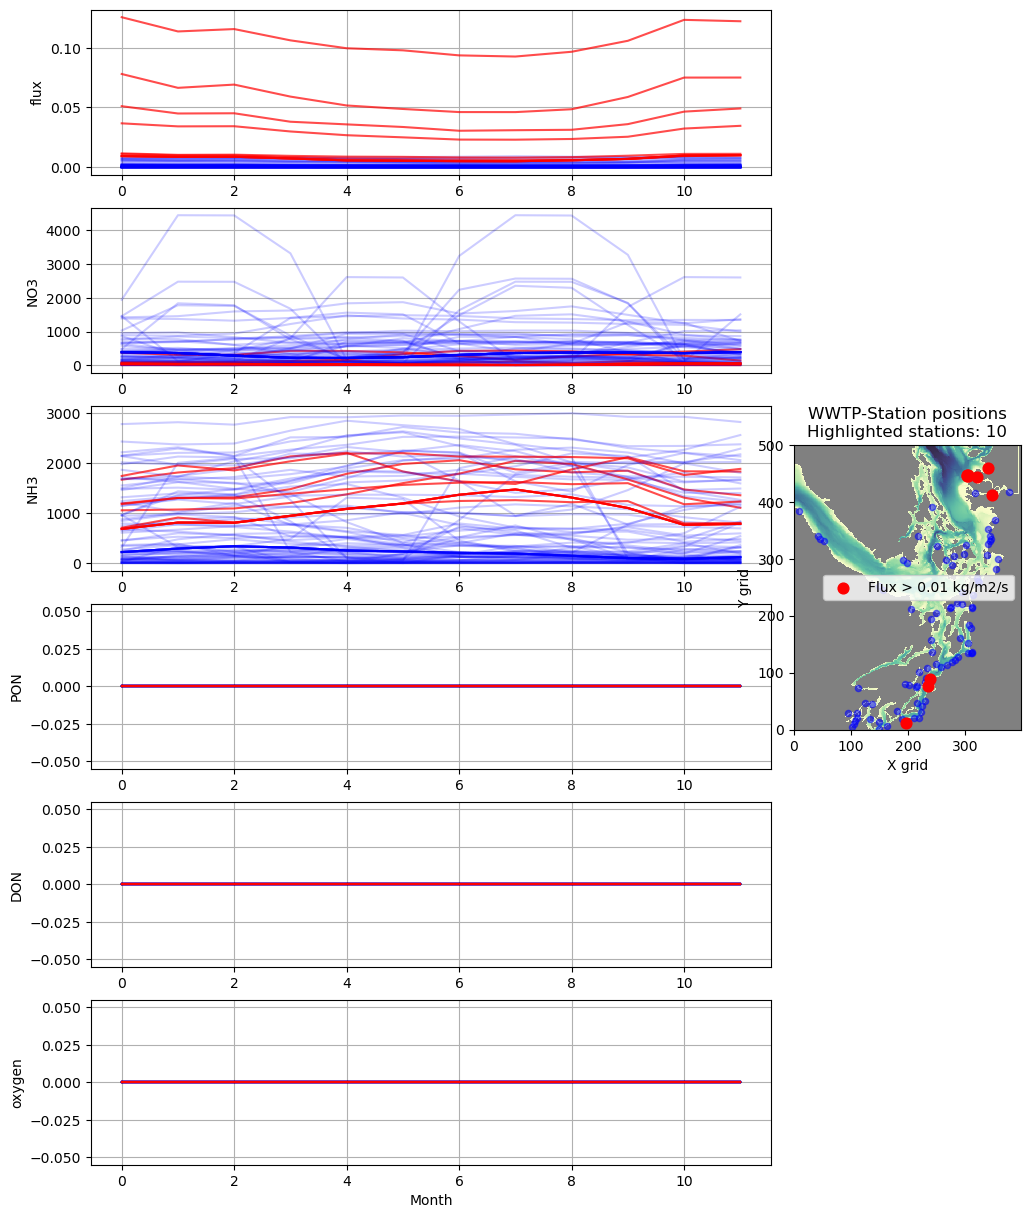

In [14]:
bathy = nc.Dataset('/ocean/atall/MOAD/grid/bathymetry_202108.nc')
import matplotlib.gridspec as gridspec

time = ds["time_counter"].values
threshold = 0.01

# Colormap for bathymetry
mycmap = cm.deep
mycmap.set_bad('grey')

vars_to_plot = ["flux", "NO3", "NH3", "PON", "DON", "oxygen"]
n_vars = len(vars_to_plot)

# Create figure with GridSpec
fig = plt.figure(figsize=(12, 15))
gs = gridspec.GridSpec(n_vars, 2, width_ratios=[3, 1], wspace=0.05)

axes = []

# Left: time series axes (n_vars rows)
for i in range(n_vars):
    ax = fig.add_subplot(gs[i,0])
    axes.append(ax)

highlighted_stations = []

# Time series plots (left)
for idx, (iy, ix) in enumerate(source_indices):
    for i, var in enumerate(vars_to_plot):
        data = ds[var][:, iy, ix].values
        
        if ds["flux"][:, iy, ix].max() > threshold:
            axes[i].plot(time, data, color="red", alpha=0.7)
            highlighted_stations.append((iy, ix))
        else:
            axes[i].plot(time, data, color="blue", alpha=0.2)
        
        axes[i].set_ylabel(var)
        axes[i].grid(True)

axes[-1].set_xlabel("Month")

highlighted_stations = list(dict.fromkeys(highlighted_stations)) # Remove duplicates

# Right: map axis 
ax_map = fig.add_subplot(gs[:,1])  # span all rows

bathy_data = bathy.variables['Bathymetry'][:]
ax_map.pcolormesh(bathy_data, cmap=mycmap, vmin=0, vmax=450)

all_y, all_x = zip(*source_indices)
ax_map.scatter(all_x, all_y, color='blue', alpha=0.5, s=20)

highlight_y, highlight_x = zip(*highlighted_stations)
ax_map.scatter(highlight_x, highlight_y, color='red', s=60, label='Flux > 0.01 kg/m2/s') # Highlight stations

ax_map.set_title(f"WWTP-Station positions\nHighlighted stations: {len(highlighted_stations)}")
ax_map.set_xlabel("X grid")
ax_map.set_ylabel("Y grid")
ax_map.set_ylim(0, 500)
ax_map.legend()
ax_map.set_aspect('equal')

#plt.tight_layout()
#plt.show()